# Анализ результатов: Favorita Sales Forecasting

Ноутбук с ключевыми визуализациями результатов эксперимента по HW3.
Все графики сохранены в папке `results/`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-darkgrid")
RESULTS = Path("..") / "results"
%matplotlib inline

## 1. Сравнение моделей

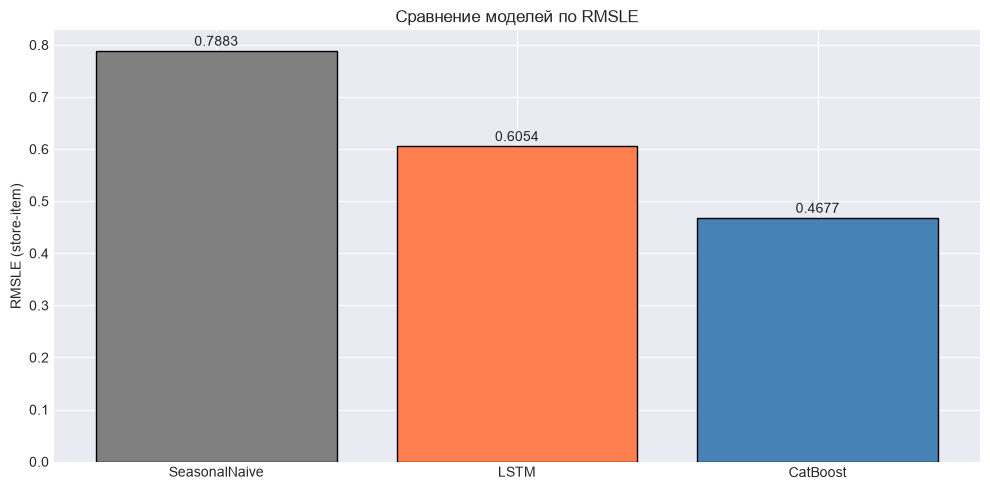

,Модель,RMSLE,Тип
0,SeasonalNaive,0.7883,бейзлайн
1,LSTM,0.6054,DL
2,CatBoost,0.4677,ML


In [2]:
results = pd.DataFrame({
    "Модель": ["SeasonalNaive", "LSTM", "CatBoost"],
    "RMSLE": [0.7883, 0.6054, 0.4677],
    "Тип": ["бейзлайн", "DL", "ML"],
})

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["gray", "coral", "steelblue"]
bars = ax.bar(results["Модель"], results["RMSLE"], color=colors, edgecolor="black")
ax.set_ylabel("RMSLE (store-item)")
ax.set_title("Сравнение моделей по RMSLE")
for bar, val in zip(bars, results["RMSLE"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.4f}", ha="center")
plt.tight_layout()
plt.show()

results

## 2. Feature Importance (CatBoost, Top-15)

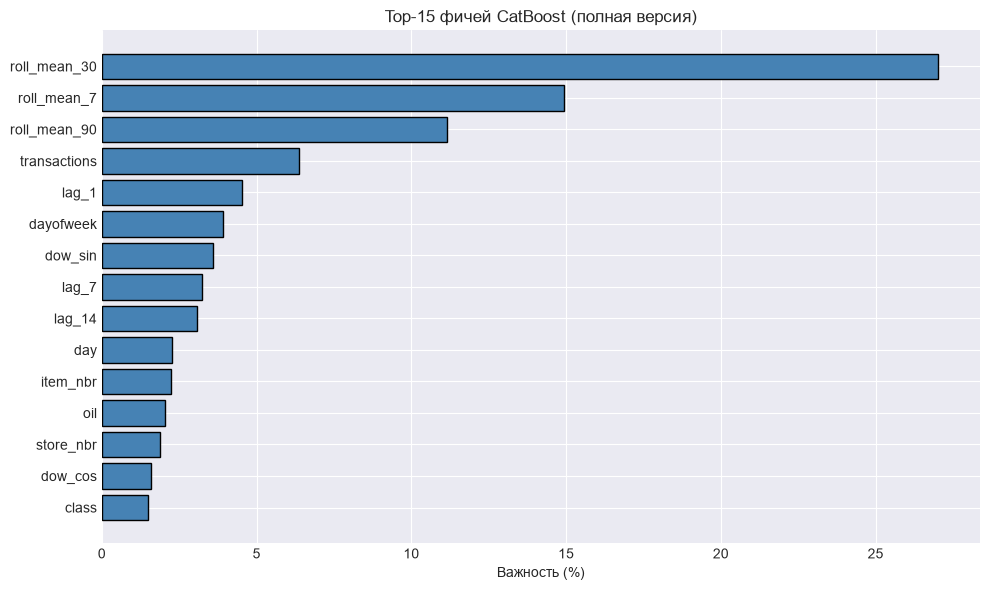

In [3]:
imp = pd.read_csv(RESULTS / "catboost_importance_full.csv")
top = imp.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top["feature"], top["importance"], color="steelblue", edgecolor="black")
ax.set_xlabel("Важность (%)")
ax.set_title("Top-15 фичей CatBoost (полная версия)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. LSTM: динамика по эпохам

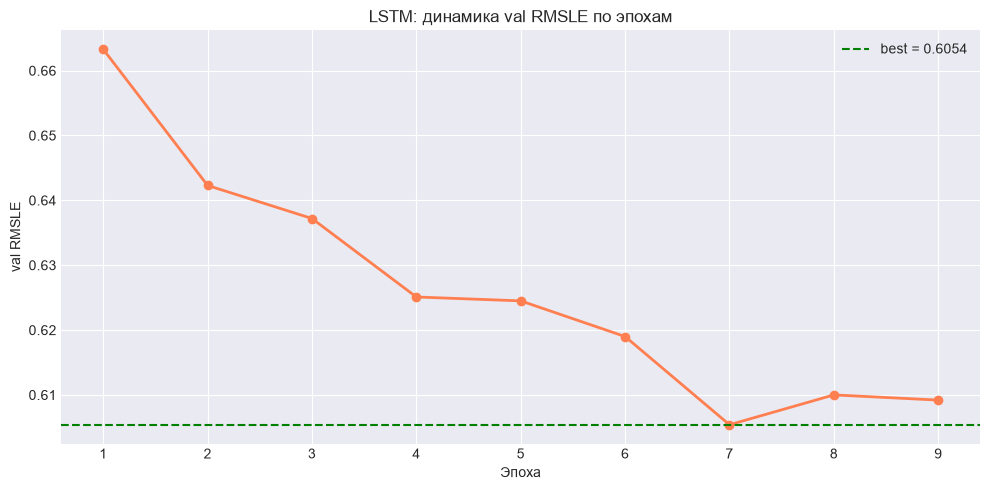

In [4]:
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9]
val_rmsle = [0.6633, 0.6423, 0.6372, 0.6251, 0.6245, 0.6190, 0.6054, 0.6100, 0.6092]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, val_rmsle, marker="o", linewidth=2, color="coral")
ax.axhline(y=min(val_rmsle), color="green", linestyle="--",
           label=f"best = {min(val_rmsle)}")
ax.set_xlabel("Эпоха")
ax.set_ylabel("val RMSLE")
ax.set_title("LSTM: динамика val RMSLE по эпохам")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 4. Выводы

- **CatBoost (ML)** — лучшая модель: RMSLE = 0.4677.
- **LSTM (DL)** — RMSLE = 0.6054, уступает CatBoost, но превосходит бейзлайн.
- **SeasonalNaive (бейзлайн)** — RMSLE = 0.7883.
- Прирост от ML: **−41% ошибки** относительно бейзлайна.
- На Kaggle: **Public Score = 1.03390** (на полном тесте, где 90% пар — незнакомые).